In [1]:
from scipy.io import arff
import pandas as pd

# โหลดไฟล์ .arff
data, meta = arff.loadarff('Data/weather.numeric.arff')

# แปลงเป็น Pandas DataFrame
df = pd.DataFrame(data)

# แสดงตัวอย่างข้อมูล
df


,outlook,temperature,humidity,windy,play
0,b'sunny',85.0,85.0,b'FALSE',b'no'
1,b'sunny',80.0,90.0,b'TRUE',b'no'
2,b'overcast',83.0,86.0,b'FALSE',b'yes'
3,b'rainy',70.0,96.0,b'FALSE',b'yes'
4,b'rainy',68.0,80.0,b'FALSE',b'yes'
5,b'rainy',65.0,70.0,b'TRUE',b'no'
6,b'overcast',64.0,65.0,b'TRUE',b'yes'
7,b'sunny',72.0,95.0,b'FALSE',b'no'
8,b'sunny',69.0,70.0,b'FALSE',b'yes'
9,b'rainy',75.0,80.0,b'FALSE',b'yes'


In [2]:
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

df

C:\Users\Pond0\AppData\Local\Temp\ipykernel_28492\3145443094.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


,outlook,temperature,humidity,windy,play
0,sunny,85.0,85.0,FALSE,no
1,sunny,80.0,90.0,TRUE,no
2,overcast,83.0,86.0,FALSE,yes
3,rainy,70.0,96.0,FALSE,yes
4,rainy,68.0,80.0,FALSE,yes
5,rainy,65.0,70.0,TRUE,no
6,overcast,64.0,65.0,TRUE,yes
7,sunny,72.0,95.0,FALSE,no
8,sunny,69.0,70.0,FALSE,yes
9,rainy,75.0,80.0,FALSE,yes


In [3]:
duplicate_df = df[df.duplicated()]
print("Number of duplicate rows", duplicate_df.shape)

Number of duplicate rows (0, 5)


In [4]:
from sklearn.preprocessing import LabelEncoder

le_Outlook = LabelEncoder()
le_Windy = LabelEncoder()
le_Play = LabelEncoder()

df['outlook_en'] = le_Outlook.fit_transform(df['outlook'])
df['windy_en'] = le_Windy.fit_transform(df['windy'])
df['play_en'] = le_Play.fit_transform(df['play'])

print(dict(enumerate(le_Outlook.classes_)))
print(dict(enumerate(le_Windy.classes_)))
print(dict(enumerate(le_Play.classes_)))

{0: 'overcast', 1: 'rainy', 2: 'sunny'}
{0: 'FALSE', 1: 'TRUE'}
{0: 'no', 1: 'yes'}


In [5]:
df

,outlook,temperature,humidity,windy,play,outlook_en,windy_en,play_en
0,sunny,85.0,85.0,FALSE,no,2,0,0
1,sunny,80.0,90.0,TRUE,no,2,1,0
2,overcast,83.0,86.0,FALSE,yes,0,0,1
3,rainy,70.0,96.0,FALSE,yes,1,0,1
4,rainy,68.0,80.0,FALSE,yes,1,0,1
5,rainy,65.0,70.0,TRUE,no,1,1,0
6,overcast,64.0,65.0,TRUE,yes,0,1,1
7,sunny,72.0,95.0,FALSE,no,2,0,0
8,sunny,69.0,70.0,FALSE,yes,2,0,1
9,rainy,75.0,80.0,FALSE,yes,1,0,1


In [6]:
df = df.drop(['outlook', 'windy', 'play', 'outlook_en', 'windy_en', 'play_en'], axis=1)

df

,temperature,humidity
0,85.0,85.0
1,80.0,90.0
2,83.0,86.0
3,70.0,96.0
4,68.0,80.0
5,65.0,70.0
6,64.0,65.0
7,72.0,95.0
8,69.0,70.0
9,75.0,80.0


In [7]:
import numpy as np

x1 = df['humidity']
x2 = df['temperature']
noise = np.random.randn(14) * 2
y = 3*x1 + 2*x2 + 5 + noise

df['y'] = y

df

,temperature,humidity,y
0,85.0,85.0,428.916940
1,80.0,90.0,435.611770
2,83.0,86.0,428.632867
3,70.0,96.0,432.699833
4,68.0,80.0,380.943746
5,65.0,70.0,345.992419
6,64.0,65.0,327.115354
7,72.0,95.0,438.485265
8,69.0,70.0,348.235521
9,75.0,80.0,397.266992


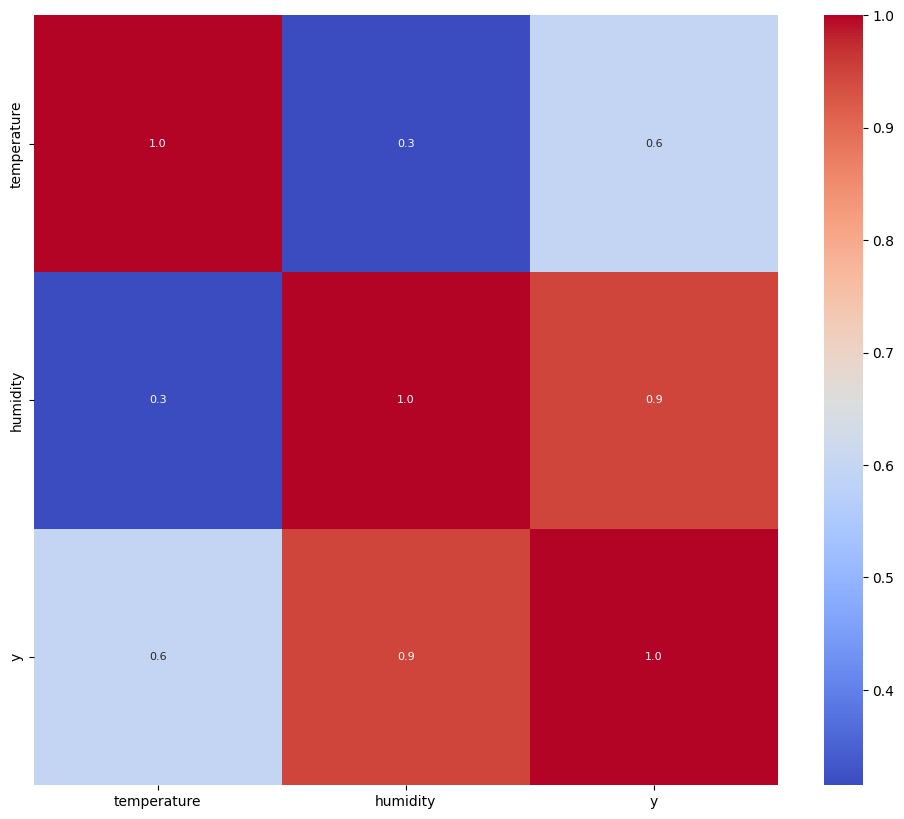

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
plt.figure(figsize=(12, 10))  # Adjust the width and height as needed

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".1f", annot_kws={"size": 8})
plt.show()

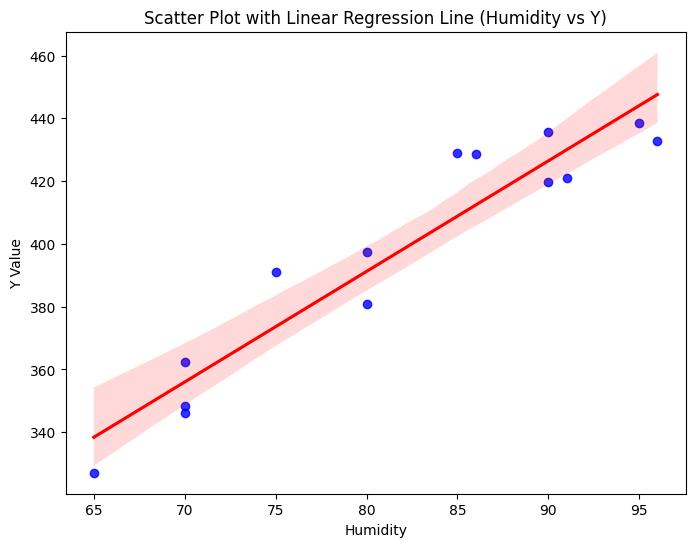

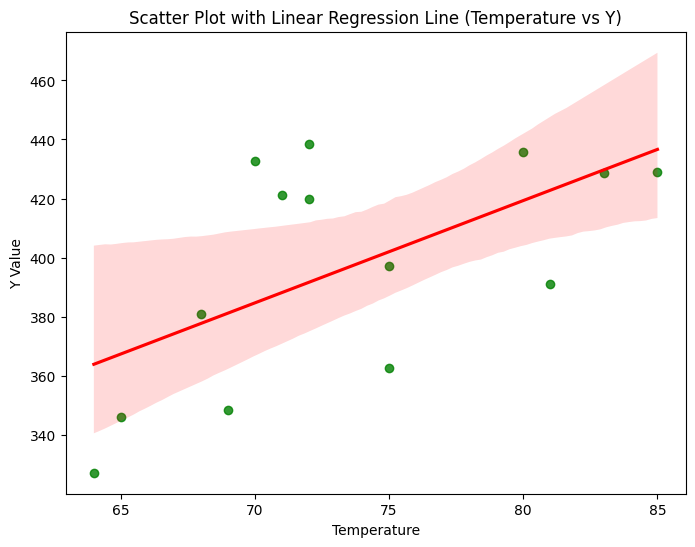

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# สร้างกราฟ Scatter และ Linear Regression
plt.figure(figsize=(8, 6))
sns.regplot(x=df['humidity'], y=df['y'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('Humidity')
plt.ylabel('Y Value')
plt.title('Scatter Plot with Linear Regression Line (Humidity vs Y)')
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x=df['temperature'], y=df['y'], scatter_kws={'color': 'green'}, line_kws={'color': 'red'})
plt.xlabel('Temperature')
plt.ylabel('Y Value')
plt.title('Scatter Plot with Linear Regression Line (Temperature vs Y)')
plt.show()


In [10]:
df

,temperature,humidity,y
0,85.0,85.0,428.916940
1,80.0,90.0,435.611770
2,83.0,86.0,428.632867
3,70.0,96.0,432.699833
4,68.0,80.0,380.943746
5,65.0,70.0,345.992419
6,64.0,65.0,327.115354
7,72.0,95.0,438.485265
8,69.0,70.0,348.235521
9,75.0,80.0,397.266992


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_x = df.drop(['y'], axis=1)
x1 = df_x['temperature']
x2 = df_x['humidity']
df_y = df['y']
y = df['y']

df_x = df_x.to_numpy()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB  # ไม่มีเวอร์ชัน Regression ที่ตรงตัว
from sklearn.neighbors import KNeighborsRegressor


from sklearn.metrics import accuracy_score



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=42) # You can adjust test_size and random_state


# Define a dictionary of models to evaluate
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "SVR": SVR(),
    "KNeighborsRegressor": KNeighborsRegressor()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    print(f"{name} MAE: {MAE} MSE: {MSE} R-Squared: {R2}")

LinearRegression MAE: 1.177515090668578 MSE: 2.7332880582430525 R-Squared: 0.9845577352720581
DecisionTreeRegressor MAE: 10.801028389012382 MSE: 172.01176161265462 R-Squared: 0.02818469823130476
RandomForestRegressor MAE: 9.9678022469411 MSE: 99.75453828345552 R-Squared: 0.43641652282455756
SVR MAE: 21.98778646099758 MSE: 632.7918629421566 R-Squared: -2.5750858515518242
KNeighborsRegressor MAE: 3.4545283392625947 MSE: 15.068205564753924 R-Squared: 0.9148691194094092


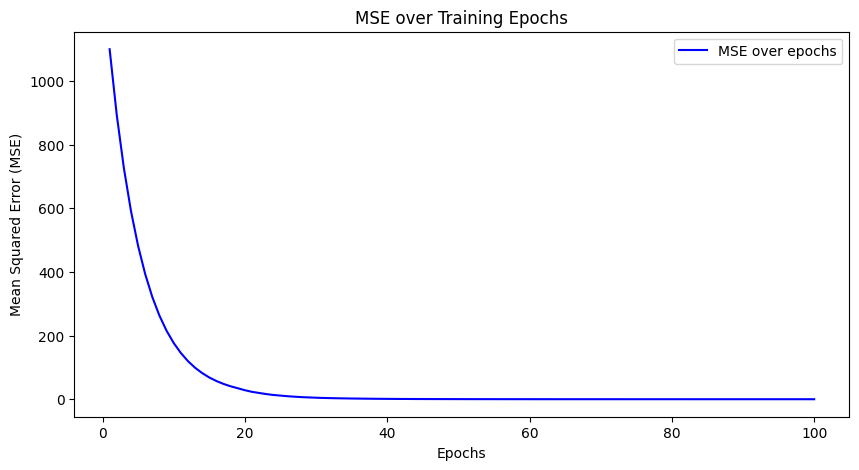

Epoch 10: MAE = 11.5645 - MSE = 176.7033 - MSEE = 176.7033
Epoch 20: MAE = 4.3995 - MSE = 28.2989 - MSEE = 28.2989
Epoch 30: MAE = 1.7522 - MSE = 4.7491 - MSEE = 4.7491
Epoch 40: MAE = 0.8509 - MSE = 1.1006 - MSEE = 1.1006
Epoch 50: MAE = 0.4251 - MSE = 0.3266 - MSEE = 0.3266
Epoch 60: MAE = 0.2335 - MSE = 0.0889 - MSEE = 0.0889
Epoch 70: MAE = 0.1388 - MSE = 0.0309 - MSEE = 0.0309
Epoch 80: MAE = 0.0977 - MSE = 0.0174 - MSEE = 0.0174
Epoch 90: MAE = 0.0661 - MSE = 0.0081 - MSEE = 0.0081
Epoch 100: MAE = 0.0435 - MSE = 0.0032 - MSEE = 0.0032
     y = 1.1847x1 + 2.0422x2 + 143.1279
     y = 1.6093x1 + 2.7576x2 + 53.4851
     y = 1.7889x1 + 3.0070x2 + 19.9105
     y = 1.8654x1 + 3.0911x2 + 7.4104
     y = 1.8958x1 + 3.1206x2 + 2.7701
     y = 1.9087x1 + 3.1311x2 + 0.9685
     y = 1.9158x1 + 3.1331x2 + 0.2734
     y = 1.9188x1 + 3.1342x2 + -0.0337
     y = 1.9201x1 + 3.1346x2 + -0.1612
     y = 1.9206x1 + 3.1346x2 + -0.1999


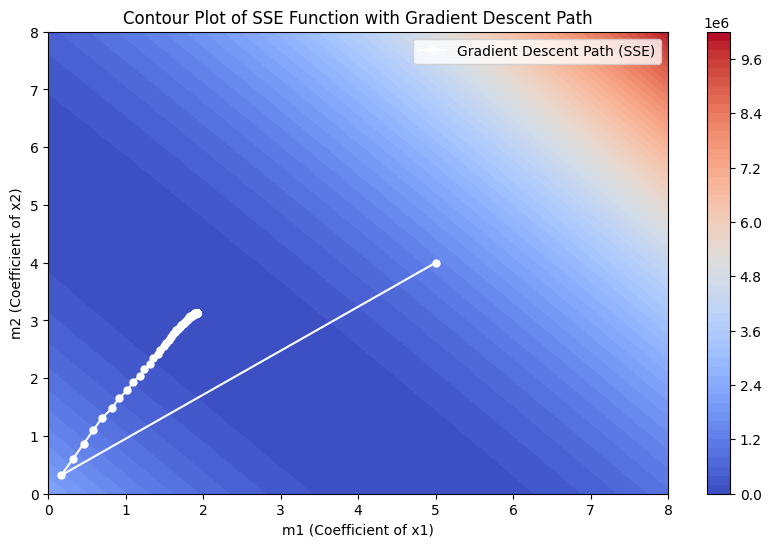

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression

# สร้างตัวเรียนรู้แบบ Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42)

# เก็บค่าความสูญเสียในแต่ละรอบ
mae_values = []
mse_values = []
msee_values = []
equations_sse = []
C_values = [5]
m1_vals = [5]
m2_vals = [4]
equations = []

# ฝึกโมเดลและบันทึกค่า error และค่าคงที่ C
for epoch in range(1, 101):  # จำนวนรอบที่ฝึก
    gbr.n_estimators = epoch  # ปรับจำนวน estimators ตามรอบ
    gbr.fit(df_x, df_y)
    y_pred = gbr.predict(df_x)
    
    mse = mean_squared_error(df_y, y_pred)
    mae = mean_absolute_error(df_y, y_pred)
    msee = np.mean((df_y - y_pred) ** 2)  # คำนวณ MSEE ใหม่
    C = np.mean(df_y - y_pred)  # ค่า C = ค่าเฉลี่ยของ residuals
    mse_values.append(mse)
    mae_values.append(mae)
    msee_values.append(msee)

    X_design = np.column_stack((x1, x2, np.ones_like(x1)))  # [x1, x2, intercept]
    coef_approx, _, _, _ = np.linalg.lstsq(X_design, y_pred, rcond=None)
    m1, m2, ccc  = coef_approx[0], coef_approx[1], coef_approx[2]
    m1_vals.append(m1)
    m2_vals.append(m2)
    C_values.append(ccc)
    
    if epoch % 10 == 0:
        equations_sse.append(f"Epoch {epoch}: MAE = {mae:.4f} - MSE = {mse:.4f} - MSEE = {msee:.4f}")
        equations.append(f"     y = {m1:.4f}x1 + {m2:.4f}x2 + {ccc:.4f}")

# Plot ค่า MSE ในแต่ละ epoch
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mse_values) + 1), mse_values, label="MSE over epochs", color="blue")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE over Training Epochs")
plt.legend()
plt.show()

# แสดงค่า C ที่บันทึกไว้ทุก epoch
for eq in equations_sse:
    print(eq)

for eq_y in equations:
    print(eq_y)

m1_range, m2_range = np.linspace(0, 8, 50), np.linspace(0, 8, 50)
M1, M2 = np.meshgrid(m1_range, m2_range)
Error_SSE = np.array([[np.sum((y - (m1_ * x1 + m2_ * x2))**2) 
                       for m2_ in m2_range] for m1_ in m1_range])

# Plot Contour
plt.figure(figsize=(10, 6))
contour = plt.contourf(M1, M2, Error_SSE, levels=50, cmap="coolwarm")
plt.colorbar(contour)

# Plot เส้นทางของ Gradient Descent
plt.plot(m1_vals, m2_vals, 'wo-', markersize=5, label="Gradient Descent Path (SSE)")

plt.xlabel("m1 (Coefficient of x1)")
plt.ylabel("m2 (Coefficient of x2)")
plt.title("Contour Plot of SSE Function with Gradient Descent Path")
plt.legend()
plt.show()




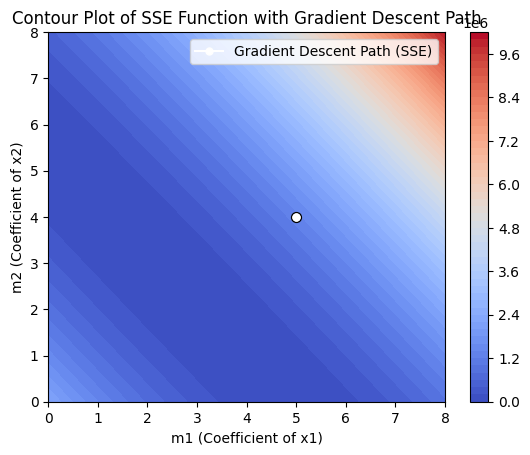

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# สร้างค่าของ m1 และ m2 ที่ใช้ใน Gradient Descent
m1_range, m2_range = np.linspace(0, 8, 50), np.linspace(0, 8, 50)
M1, M2 = np.meshgrid(m1_range, m2_range)

# คำนวณ Error SSE
Error_SSE = np.array([[np.sum((y - (m1_ * x1 + m2_ * x2))**2) 
                       for m2_ in m2_range] for m1_ in m1_range])

# เตรียมข้อมูลสำหรับ Animation
fig, ax = plt.subplots()
contour = ax.contourf(M1, M2, Error_SSE, levels=50, cmap="coolwarm")
plt.colorbar(contour)

# Plot จุดเริ่มต้น
scat = ax.scatter([], [], c='white', edgecolor='black', s=50)
line, = ax.plot([], [], 'wo-', markersize=5, label="Gradient Descent Path (SSE)")

ax.set(xlabel="m1 (Coefficient of x1)", ylabel="m2 (Coefficient of x2)", 
       title="Contour Plot of SSE Function with Gradient Descent Path")
ax.legend()

# ฟังก์ชันอัปเดต Animation
def update(frame):
    line.set_data(m1_vals[:frame+1], m2_vals[:frame+1])
    scat.set_offsets(np.c_[m1_vals[frame], m2_vals[frame]])
    return line, scat

frames = len(m1_vals)
ani = animation.FuncAnimation(fig=fig, func=update, frames=frames, interval=200)

HTML(ani.to_jshtml())



In [17]:
'''import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression

# ค่าต่างๆ ที่ใช้ในการเก็บค่า
slope_stack = []
y_intercept_stack = []

# สร้างตัวเรียนรู้แบบ Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=1, learning_rate=0.1, max_depth=3, random_state=42, warm_start=True)

# ฝึกโมเดลและบันทึกค่าความชันและจุดตัดแกน y
for epoch in range(1, 51):  # จำนวนรอบของ training
    gbr.n_estimators = epoch  # ปรับ estimators
    gbr.fit(df_x, df_y)
    y_pred = gbr.predict(df_x)

    coef_approx = np.polyfit(df_x[:, 0], y_pred, 1)  # ใช้คุณลักษณะตัวแรก
    slope_stack.append(coef_approx[0])
    y_intercept_stack.append(coef_approx[1])

# เตรียมข้อมูลสำหรับ animation
x = np.linspace(min(df_x[:, 0]), max(df_x[:, 0]), 100)

fig, ax = plt.subplots()
scat = ax.scatter(df_x[:, 0], df_y, c="#41B06E")
line, = ax.plot(x, slope_stack[0] * x + y_intercept_stack[0], color='red')
ax.set(ylim=[min(df_y) - 10, max(df_y) + 10], xlim=[min(df_x[:, 0]) - 1, max(df_x[:, 0]) + 1], xlabel='x', ylabel='y')

def update(frame):
    line.set_ydata(slope_stack[frame] * x + y_intercept_stack[frame])
    ax.set_title(f"y = {slope_stack[frame]:.6f}x + {y_intercept_stack[frame]:.6f}")
    return scat, line

frames = len(slope_stack)
ani = animation.FuncAnimation(fig=fig, func=update, frames=frames, interval=200)

# แสดง animation
from IPython.display import HTML
HTML(ani.to_jshtml())
'''

'import numpy as np\nimport matplotlib.pyplot as plt\nimport matplotlib.animation as animation\nfrom sklearn.ensemble import GradientBoostingRegressor\nfrom sklearn.metrics import mean_squared_error, mean_absolute_error\nfrom sklearn.datasets import make_regression\n\n# ค่าต่างๆ ที่ใช้ในการเก็บค่า\nslope_stack = []\ny_intercept_stack = []\n\n# สร้างตัวเรียนรู้แบบ Gradient Boosting\ngbr = GradientBoostingRegressor(n_estimators=1, learning_rate=0.1, max_depth=3, random_state=42, warm_start=True)\n\n# ฝึกโมเดลและบันทึกค่าความชันและจุดตัดแกน y\nfor epoch in range(1, 51):  # จำนวนรอบของ training\n    gbr.n_estimators = epoch  # ปรับ estimators\n    gbr.fit(df_x, df_y)\n    y_pred = gbr.predict(df_x)\n\n    coef_approx = np.polyfit(df_x[:, 0], y_pred, 1)  # ใช้คุณลักษณะตัวแรก\n    slope_stack.append(coef_approx[0])\n    y_intercept_stack.append(coef_approx[1])\n\n# เตรียมข้อมูลสำหรับ animation\nx = np.linspace(min(df_x[:, 0]), max(df_x[:, 0]), 100)\n\nfig, ax = plt.subplots()\nscat = ax.scat

In [18]:
x1 = df_x[:, 0]
x2 = df_x[:, 1]
y = df['y']
print(x1)
print(x2)
print(y)

[85. 80. 83. 70. 68. 65. 64. 72. 69. 75. 75. 72. 81. 71.]
[85. 90. 86. 96. 80. 70. 65. 95. 70. 80. 70. 90. 75. 91.]
0     428.916940
1     435.611770
2     428.632867
3     432.699833
4     380.943746
5     345.992419
6     327.115354
7     438.485265
8     348.235521
9     397.266992
10    362.449109
11    419.816004
12    391.045045
13    421.107167
Name: y, dtype: float64


In [19]:
'''import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression


y = df['y']
x1 = df_x[:, 0]  # ตัวแปร x1
x2 = df_x[:, 1]  # ตัวแปร x2 ใช้สำหรับเชดสี

# ค่าต่างๆ ที่ใช้ในการเก็บค่า
slope_stack = []
y_intercept_stack = []

# โมเดล Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=1, learning_rate=0.1, max_depth=3, random_state=42, warm_start=True)

# ฝึกโมเดลและบันทึกค่าความชันและจุดตัดแกน Y
for epoch in range(1, 51):  # จำนวนรอบของ training
    gbr.n_estimators = epoch  # ปรับ estimators
    gbr.fit(df_x, y)
    y_pred = gbr.predict(df_x)
    
    coef_approx = np.polyfit(x1, y_pred, 1)  # ประมาณค่าความสัมพันธ์เชิงเส้นระหว่าง x1 และ y_pred
    slope_stack.append(coef_approx[0])
    y_intercept_stack.append(coef_approx[1])

# เตรียมข้อมูลสำหรับ animation
x_range = np.linspace(min(x1), max(x1), 100)

fig, ax = plt.subplots()
scat = ax.scatter(x1, y, c=x2, cmap='viridis', edgecolor='k', alpha=0.7)
line, = ax.plot(x_range, slope_stack[0] * x_range + y_intercept_stack[0], color='red', linewidth=2)

ax.set(
    xlabel='x1',
    ylabel='Predicted y',
    title='Gradient Boosting Regression Progression'
)
fig.colorbar(scat, label='x2 Value')

def update(frame):
    line.set_ydata(slope_stack[frame] * x_range + y_intercept_stack[frame])
    ax.set_title(f"Epoch {frame+1}: y = {slope_stack[frame]:.4f}x1 + {y_intercept_stack[frame]:.4f}")
    return scat, line

frames = len(slope_stack)
ani = animation.FuncAnimation(fig=fig, func=update, frames=frames, interval=200)

# แสดง animation
from IPython.display import HTML
HTML(ani.to_jshtml())
'''

'import numpy as np\nimport matplotlib.pyplot as plt\nimport matplotlib.animation as animation\nfrom sklearn.ensemble import GradientBoostingRegressor\nfrom sklearn.metrics import mean_squared_error\nfrom sklearn.datasets import make_regression\n\n\ny = df[\'y\']\nx1 = df_x[:, 0]  # ตัวแปร x1\nx2 = df_x[:, 1]  # ตัวแปร x2 ใช้สำหรับเชดสี\n\n# ค่าต่างๆ ที่ใช้ในการเก็บค่า\nslope_stack = []\ny_intercept_stack = []\n\n# โมเดล Gradient Boosting Regressor\ngbr = GradientBoostingRegressor(n_estimators=1, learning_rate=0.1, max_depth=3, random_state=42, warm_start=True)\n\n# ฝึกโมเดลและบันทึกค่าความชันและจุดตัดแกน Y\nfor epoch in range(1, 51):  # จำนวนรอบของ training\n    gbr.n_estimators = epoch  # ปรับ estimators\n    gbr.fit(df_x, y)\n    y_pred = gbr.predict(df_x)\n    \n    coef_approx = np.polyfit(x1, y_pred, 1)  # ประมาณค่าความสัมพันธ์เชิงเส้นระหว่าง x1 และ y_pred\n    slope_stack.append(coef_approx[0])\n    y_intercept_stack.append(coef_approx[1])\n\n# เตรียมข้อมูลสำหรับ animation\nx_ra

In [21]:
df

,temperature,humidity,y
0,85.0,85.0,428.916940
1,80.0,90.0,435.611770
2,83.0,86.0,428.632867
3,70.0,96.0,432.699833
4,68.0,80.0,380.943746
5,65.0,70.0,345.992419
6,64.0,65.0,327.115354
7,72.0,95.0,438.485265
8,69.0,70.0,348.235521
9,75.0,80.0,397.266992
